# Survival Statistics

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from lifelines.exceptions import ConvergenceError
from lifelines.calibration import survival_probability_calibration
import matplotlib.pyplot as plt
import forestplot as fp

In [2]:
# Load formatted cytokines data
cytokines_df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260731.csv")

In [3]:
# Encode survival status as binary variable
cytokines_df["survival_status_encoded"] = cytokines_df["survival_status"].map({"alive": 0, "death": 1})

In [4]:
cytokines_df.head()

,sample_names,sample_id,cohort,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,...,qlq30score,hn35,pathologicstage,lvi,pni,survival_status,sx_to_lastfu,survival_2yrs,ss,survival_status_encoded
0,FF301C,FF301C,LLU,29.45,25.24,90.00,6.40,3.95,4.21,3.54,...,81.62,30.56,stage_I,no,no,alive,1839,alive,1,0
1,FF302C,FF302C,LLU,71.50,9.93,46.35,0.00,0.00,2.33,3.42,...,46.11,47.78,stage_IVA,no,yes,alive,1721,alive,4,0
2,FF303C,FF303C,LLU,54.54,18.38,54.01,46.49,18.90,1.37,4.15,...,57.56,45.68,stage_IVA,yes,no,death,48,death,4,1
3,FF304C,FF304C,LLU,132.67,27.47,81.82,6.89,3.95,4.56,9.69,...,19.23,94.44,stage_IVA,no,yes,death,131,death,3,1
4,FF305C,FF305C,LLU,28.01,13.63,66.20,5.44,0.92,3.04,2.42,...,76.67,17.44,stage_II,no,no,alive,1679,alive,1,0


In [5]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "ages", "sex", "race", "tobaccouse", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs", "ss"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [6]:
# Specify survival duration and event variables
T = cytokines_df["sx_to_lastfu"]
E = cytokines_df["survival_status_encoded"]

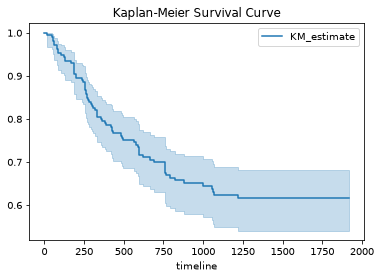

In [7]:
# Kaplan-Meier Survival Analysis
kmf = KaplanMeierFitter()
kmf.fit(
    durations=T,
    event_observed=E
)
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.show()

In [8]:
numeric_cols = cytokines_df[cytokines].drop(columns=["hbegf", "tgfalpha"]).columns

# Standardize the cytokines based on cohort (due to different platforms)
scaler = StandardScaler()
cytokines_df[numeric_cols] = (
    cytokines_df.groupby("cohort")[numeric_cols]
    .transform(lambda x: scaler.fit_transform(x.to_numpy().reshape(-1, 1)).ravel())
)

In [ ]:
# # Quantile Transformation to correct for platform differences
# def quantile_transform_two_batches(df, cytokine_cols, batch_col,
#                                      output_distribution="normal", random_state=2026):
#     """
#     Per-batch, per-cytokine quantile transformation using sklearn's QuantileTransformer.
#     Each platform's distribution is mapped independently to the same target
#     distribution (uniform or normal), removing platform-driven distributional
#     differences.

#     df: DataFrame containing cytokine columns and a batch/platform label column
#     cytokine_cols: list of cytokine column names to transform
#     batch_col: column name holding platform/batch labels
#     output_distribution: 'normal' or 'uniform'
#     """
#     df_out = df.copy()

#     for col in cytokine_cols:
#         for batch in df[batch_col].unique():
#             mask = df[batch_col] == batch
#             x = df.loc[mask, [col]].values

#             n_quantiles = min(len(x), 1000)
#             qt = QuantileTransformer(
#                     output_distribution=output_distribution,
#                     n_quantiles=n_quantiles,
#                     random_state=random_state
#             )
#             df_out.loc[mask, col] = qt.fit_transform(x).ravel()

#     return df_out

# cytokines_df_norm = quantile_transform_two_batches(
#     cytokines_df, numeric_cols, batch_col="cohort", output_distribution="normal"
# )

# cytokines_df_norm

In [9]:
def univariate_roc_grouping(df, cols, outcome_col):
    """
    For each column in `cols`, compute AUC vs `outcome_col`, determine
    association direction, find the Youden's J optimal threshold, and
    assign high/low group labels accordingly.

    Returns:
        results_df: summary table with AUC, direction, threshold per variable
        df: original dataframe with new f"{col}_group" columns added
    """
    results = []

    for col in cols:
        # drop rows with missing values for this column/outcome pair
        valid = df[[col, outcome_col]].dropna()
        y_true = valid[outcome_col].values
        score = valid[col].values

        if len(np.unique(y_true)) < 2:
            print(f"Skipping {col}: outcome has only one class after dropping NaNs")
            continue

        # AUC and direction
        auc = roc_auc_score(y_true, score)
        direction = "positive" if auc >= 0.5 else "negative"

        # ROC curve + Youden's J optimal threshold
        fpr, tpr, thresholds = roc_curve(y_true, score)
        youden_j = tpr - fpr
        best_idx = np.argmax(youden_j)
        best_threshold = thresholds[best_idx]
        sensitivity = tpr[best_idx]
        specificity = 1 - fpr[best_idx]

        # assign high/low based on direction:
        # positive association -> higher values = "high" risk/group
        # negative association -> lower values = "high" risk/group
        if direction == "positive":
            group = np.where(df[col] > best_threshold, "high", "low")
        else:
            group = np.where(df[col] > best_threshold, "low", "high")

        df[f"{col}_group"] = group

        results.append({
            "variable": col,
            "auc": auc,
            "auc_abs": max(auc, 1 - auc),
            "direction": direction,
            "best_threshold": best_threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "n": len(valid),
        })

    results_df = pd.DataFrame(results).sort_values("auc_abs", ascending=False).reset_index(drop=True)
    return results_df, df

# Function call
cols_to_test = numeric_cols
outcome_col = "survival_status_encoded"

roc_summary, cytokines_df = univariate_roc_grouping(cytokines_df, cols_to_test, outcome_col)

print(roc_summary)
print(cytokines_df[[f"{c}_group" for c in cols_to_test]].apply(pd.Series.value_counts))

     variable       auc   auc_abs direction  best_threshold  sensitivity  \
0       vegfd  0.365306  0.634694  negative             inf     0.000000   
1         il6  0.625294  0.625294  positive       -0.421840     0.729730   
2         il8  0.611584  0.611584  positive       -0.431402     0.770270   
3    tnfalpha  0.581962  0.581962  positive       -0.117731     0.567568   
4        il10  0.577801  0.577801  positive       -0.444383     0.810811   
5    il1alpha  0.558020  0.558020  positive       -0.399772     0.581081   
6     tnfbeta  0.545584  0.545584  positive       -0.065295     0.351351   
7         egf  0.544653  0.544653  positive       -0.362764     0.554054   
8       vegfc  0.474050  0.525950  negative        0.342350     0.378378   
9   mip1alpha  0.520515  0.520515  positive       -0.115877     0.554054   
10  ifnalpha2  0.485067  0.514933  negative       -1.211634     0.986486   
11        il4  0.508715  0.508715  positive       -0.039649     0.351351   
12   ifngamm

## Univariate

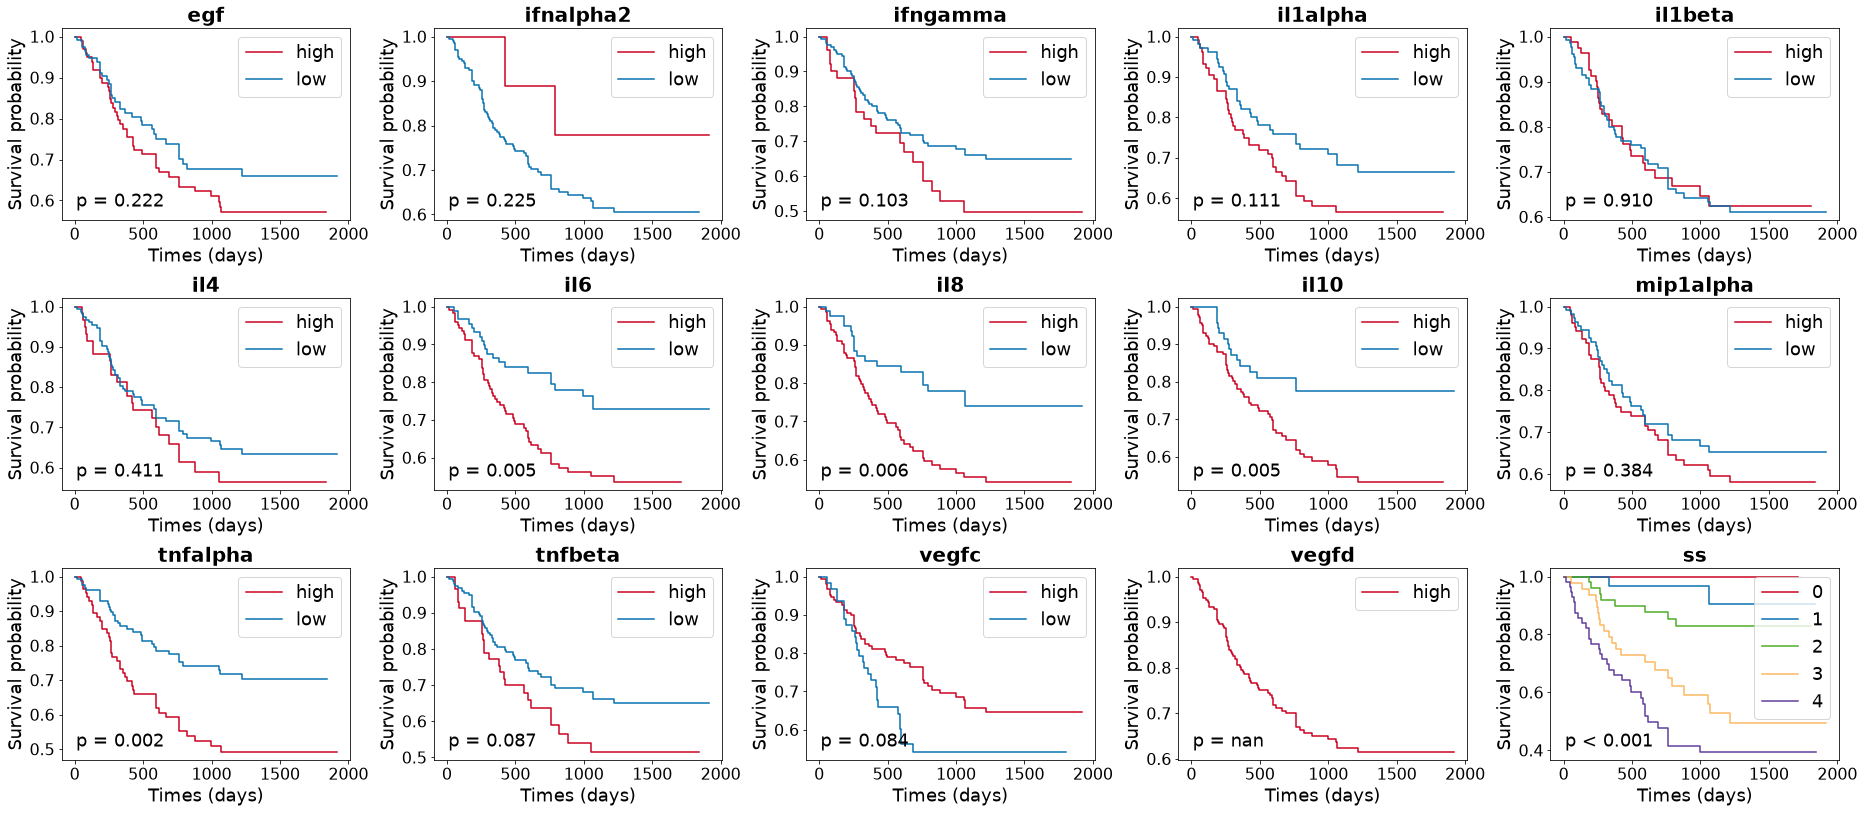

In [10]:
def plot_km_grid(df, T, E, group_cols, ncols=3, figsize_per_panel=(5.2, 3.8),
                  colors=("#CA0020", "#0571B0", "#4DAC26", "#FDB863", "#5E3C99")):
    # Set up the grid of subplots
    n = len(group_cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0]*ncols,
        figsize_per_panel[1]*nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    # Initialize the Kaplan-Meier fitter
    kmf = KaplanMeierFitter()

    # Force everything to plain numpy arrays, positionally aligned to df
    df = df.reset_index(drop=True)
    T_arr = np.asarray(T).reshape(-1)
    E_arr = np.asarray(E).reshape(-1)

    # Sanity checks asserting that the lengths of T and E match the length of the dataframe
    assert len(T_arr) == len(df), f"T length {len(T_arr)} != df length {len(df)}"
    assert len(E_arr) == len(df), f"E length {len(E_arr)} != df length {len(df)}"

    # Loop over each grouping variable and plot the Kaplan-Meier survival curves
    for i, col in enumerate(group_cols):
        ax = axes[i]
        col_vals = df[col].to_numpy()          # plain numpy array of labels
        valid = pd.notna(col_vals)
        groups = sorted(pd.unique(col_vals[valid]))

        # Loop over each group and fit the Kaplan-Meier model, plot the survival function, and perform log-rank tests
        for g, color in zip(groups, colors):
            mask = valid & (col_vals == g)      # pure boolean numpy array
            kmf.fit(durations=T_arr[mask], event_observed=E_arr[mask], label=str(g))
            kmf.plot_survival_function(ax=ax, color=color, ci_show=False)

        if len(groups) == 2:
            m0 = valid & (col_vals == groups[0])
            m1 = valid & (col_vals == groups[1])
            result = logrank_test(T_arr[m0], T_arr[m1], E_arr[m0], E_arr[m1])
        else:
            result = multivariate_logrank_test(T_arr[valid], col_vals[valid], E_arr[valid])
        p = result.p_value

        # Annotate the plot with the p-value from the log-rank test
        p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
        ax.text(0.05, 0.05, p_text, transform=ax.transAxes,
                fontsize=18, verticalalignment="bottom")

        # Set titles and labels for the axes
        ax.set_title(col.replace("_group", ""), fontweight="bold", fontsize=20)
        ax.tick_params(axis="x", labelsize=16)
        ax.tick_params(axis="y", labelsize=16)
        ax.set_xlabel("Times (days)", fontsize=18)
        ax.set_ylabel("Survival probability", fontsize=18)
        ax.legend(fontsize=18, loc="upper right")

    # Turn off any unused axes in the grid
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    return fig

# Call the function to plot Kaplan-Meier survival curves for multiple groupings
group_cols = [f"{c}_group" for c in numeric_cols] + ["ss"]
fig = plot_km_grid(cytokines_df, T, E, group_cols, ncols=5)

# Save the figure
# fig.savefig("../figures/z_score_km_grid.png", dpi=300, bbox_inches="tight")

## Multivariate

In [ ]:
# Specify the variables of interest for univariate Cox proportional hazards analysis
vars_of_interest = list(numeric_cols) + ["ss"]

results = []
failed = []

# Perform univariate Cox proportional hazards analysis for each variable of interest
for var in vars_of_interest:
    cph = CoxPHFitter()
    try:
        cph.fit(
            cytokines_df,
            duration_col="sx_to_lastfu",
            event_col="survival_status_encoded",
            formula=var
        )
        cph_summary_df = cph.summary
        results.append(cph_summary_df)
    except (ConvergenceError, ValueError) as e:
        failed.append((var, str(e)))
        print(f"Skipped '{var}': {e}")

# Combine into a single dataframe
cph_univariate_combined_summary = pd.concat(results)
cph_univariate_combined_summary = cph_univariate_combined_summary.reset_index().rename(columns={"index": "term"})
cph_univariate_combined_summary = cph_univariate_combined_summary.sort_values("p").reset_index(drop=True)

# Select significant covariates based on p-value threshold of 0.05
sig_cph_vars = cph_univariate_combined_summary[cph_univariate_combined_summary["p"] < 0.05]

print(cph_univariate_combined_summary)
print(sig_cph_vars)

    covariate      coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
0          ss  0.596783   1.816266  0.093271        0.413974        0.779591   
1         il8  0.216786   1.242079  0.089080        0.042193        0.391380   
2    tnfalpha  0.207398   1.230473  0.093441        0.024257        0.390539   
3         il6  0.173773   1.189785  0.089277       -0.001207        0.348753   
4       vegfd -0.505530   0.603186  0.306989       -1.107217        0.096158   
5         il4  0.095810   1.100550  0.097896       -0.096063        0.287684   
6     tnfbeta  0.075449   1.078369  0.088938       -0.098866        0.249765   
7         egf  0.066589   1.068856  0.107527       -0.144159        0.277337   
8        il10  0.061226   1.063139  0.102643       -0.139952        0.262403   
9    il1alpha  0.044889   1.045912  0.104067       -0.159078        0.248856   
10      vegfc  0.020375   1.020584  0.117873       -0.210652        0.251402   
11   ifngamma  0.015869   1.015995  0.10

In [14]:
# Initialize the Cox Proportional Hazards model
cph = CoxPHFitter()

# Create a formula string for the Cox model
formula = "ss + il8 + tnfalpha"

# Fit the Cox Proportional Hazards model to the data
cph.fit(
    cytokines_df,
    duration_col="sx_to_lastfu",
    event_col="survival_status_encoded",
    formula=formula
)
cph_multivariable_summary = cph.summary

print(formula)
cph_multivariable_summary

ss + il8 + tnfalpha


,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
ss,0.612815,1.845620,0.095380,0.425873,0.799757,1.530927,2.225001,0.0,6.424963,1.319017e-10,32.819818
il8,0.185159,1.203410,0.097358,-0.005659,0.375977,0.994357,1.456414,0.0,1.901835,5.719275e-02,4.128024
tnfalpha,0.168182,1.183152,0.105411,-0.038419,0.374783,0.962310,1.454676,0.0,1.595499,1.106008e-01,3.176566


In [15]:
cph.check_assumptions(cytokines_df, p_value_threshold=0.05)

Proportional hazard assumption looks okay.


[]

In [20]:
# Format data for forest plot
cph_multivariable_summary_df = cph_multivariable_summary.loc[:, ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].reset_index()
cph_multivariable_summary_df.rename(
    columns={
        "exp(coef)": "HR",
        "exp(coef) lower 95%": "HR_lower_95",
        "exp(coef) upper 95%": "HR_upper_95",
        "p": "p_value"
    },
    inplace=True
)

cph_multivariable_summary_df["label"] = cph_multivariable_summary_df["covariate"].str.extract(r"\[T\.(.*?)\]")[0]
cph_multivariable_summary_df["label"] = cph_multivariable_summary_df["label"].fillna(cph_multivariable_summary_df["covariate"])

def assign_group(cov):
    if cov.startswith("lvi"):
        return "LVI"
    elif cov.startswith("pni"):
        return "PNI"
    elif cov.startswith("pathologicstage"):
        return "Pathologic_stage"
    elif cov.startswith("ss"):
        return "Composite score"
    else:
        return "Cytokines"

cph_multivariable_summary_df["group"] = cph_multivariable_summary_df["covariate"].apply(assign_group)

cph_multivariable_summary_df

,covariate,HR,HR_lower_95,HR_upper_95,p_value,label,group
0,ss,1.845620,1.530927,2.225001,1.319017e-10,ss,Composite score
1,il8,1.203410,0.994357,1.456414,5.719275e-02,il8,Cytokines
2,tnfalpha,1.183152,0.962310,1.454676,1.106008e-01,tnfalpha,Cytokines


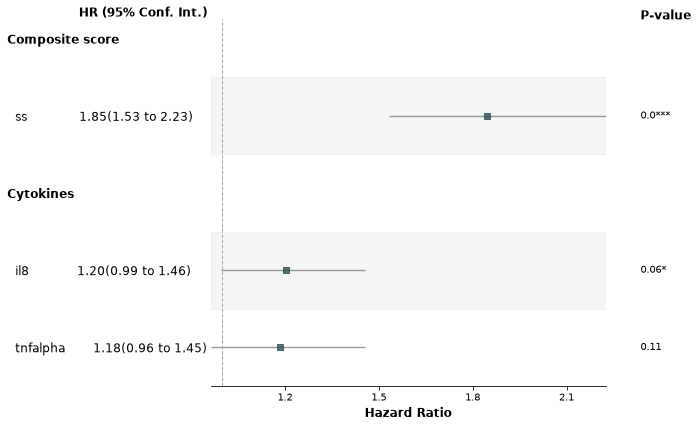

In [22]:
# Forest plot of the Multivariable Cox Proportional Hazards model results
ax = fp.forestplot(
    cph_multivariable_summary_df,
    estimate="HR",
    ll="HR_lower_95",
    hl="HR_upper_95",
    varlabel="label",
    groupvar="group",
    pval="p_value",
    ylabel="HR (95% Conf. Int.)",
    **{"ylabel1_size": 12},
    xlabel="Hazard Ratio",
    sort=True,
    color_alt_rows=True,
    logscale=False,
    **{"fontfamily": "sans-serif"}
)

# Reference line at HR = 1 (no effect)
ax.axvline(x=1, color="darkgray", linestyle="--", linewidth=1, zorder=0)

# Save the forest plot figure
fig = ax.get_figure()
fig.set_size_inches(10, 6)
# fig.savefig("../figures/cox_multivariable_forestplot.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


ICI =  0.19550861245181347
E50 =  0.15712219720154824


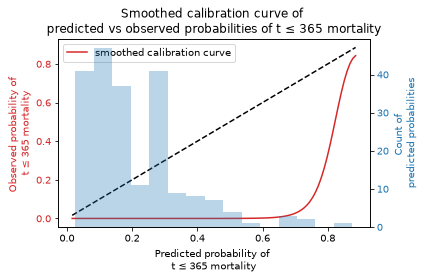

In [110]:
# cytokines_df["pathologicstage_group"] = cytokines_df["pathologicstage"].map({
#     "stage_I": "early", "stage_II": "early",
#     "stage_III": "late", "stage_IVa": "late", "stage_IVb": "late"
# })

cph = CoxPHFitter(baseline_estimation_method="spline", n_baseline_knots=2)
cph.fit(
    cytokines_df,
    duration_col="sx_to_lastfu",
    event_col="survival_status_encoded",
    formula="ss + il8"
)

ax, ici, e50 = survival_probability_calibration(cph, cytokines_df, t0=365.24)

fig = ax.get_figure()
# fig.savefig("../figures/survival_probability_calibration.png", dpi=300, bbox_inches="tight")

plt.show()